# EDA — Populism and Political Corruption (V-Dem / V-Party)

Research question: do countries governed by populist parties exhibit higher political
corruption, which dimension is most affected, and in which temporal direction does the
relationship run?

This notebook covers:
- **Section 0** — Setup & connection
- **Section 1** — Data overview & coverage

See `notes_for_report.md` at the repo root for the full write-up of decisions and findings.

## Section 0 — Setup & connection

In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

sns.set_theme(style="whitegrid")
pl.Config.set_tbl_rows(20)

# Window enforced throughout: V-Party expert-coded variables only exist 1970-2019.
ANALYSIS_START_YEAR = 1970
ANALYSIS_END_YEAR = 2019

DB_PATH = Path("../data/duckdb/vdem.duckdb")
con = duckdb.connect(str(DB_PATH), read_only=True)

In [2]:
# Confirm the expected tables are present.
pl.read_database(
    "SELECT table_schema, table_name FROM information_schema.tables ORDER BY 1, 2",
    con,
)

table_schema,table_name
str,str
"""meta""","""analysis_window"""
"""meta""","""import_summary"""
"""raw""","""vdem_country_year"""
"""raw""","""vparty_country_party_date"""


## Section 1 — Data overview & coverage

### 1a. Temporal & geographic coverage, 1970–2019

In [3]:
coverage_summary = pl.read_database(
    f"""
    SELECT
        'vdem_country_year' AS table_name,
        MIN(year) AS min_year,
        MAX(year) AS max_year,
        COUNT(DISTINCT country_id) AS n_countries,
        COUNT(*) AS n_rows
    FROM raw.vdem_country_year
    WHERE year BETWEEN {ANALYSIS_START_YEAR} AND {ANALYSIS_END_YEAR}

    UNION ALL

    SELECT
        'vparty_country_party_date' AS table_name,
        MIN(year) AS min_year,
        MAX(year) AS max_year,
        COUNT(DISTINCT country_id) AS n_countries,
        COUNT(*) AS n_rows
    FROM raw.vparty_country_party_date
    WHERE year BETWEEN {ANALYSIS_START_YEAR} AND {ANALYSIS_END_YEAR}
    """,
    con,
)
coverage_summary

table_name,min_year,max_year,n_countries,n_rows
str,i64,i64,i64,i64
"""vdem_country_year""",1970,2019,182,8454
"""vparty_country_party_date""",1970,2019,178,7518


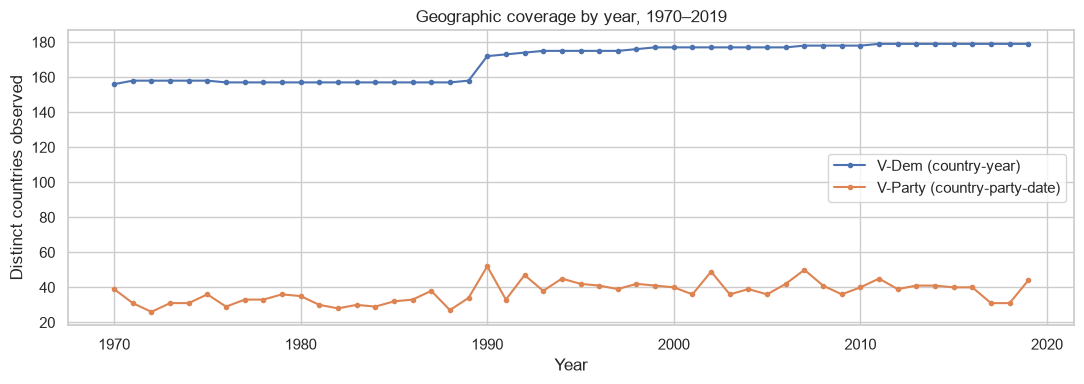

In [4]:
# Geographic density by year: V-Dem is (near-)complete every year; V-Party is
# only observed in years where some country held an election. This is the direct
# evidence for the forward-fill assumption documented in notes_for_report.md.
vdem_by_year = pl.read_database(
    f"""
    SELECT year, COUNT(DISTINCT country_id) AS n_countries
    FROM raw.vdem_country_year
    WHERE year BETWEEN {ANALYSIS_START_YEAR} AND {ANALYSIS_END_YEAR}
    GROUP BY year ORDER BY year
    """,
    con,
)

vparty_by_year = pl.read_database(
    f"""
    SELECT year, COUNT(DISTINCT country_id) AS n_countries
    FROM raw.vparty_country_party_date
    WHERE year BETWEEN {ANALYSIS_START_YEAR} AND {ANALYSIS_END_YEAR}
    GROUP BY year ORDER BY year
    """,
    con,
)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(vdem_by_year["year"], vdem_by_year["n_countries"],
        label="V-Dem (country-year)", marker="o", markersize=3)
ax.plot(vparty_by_year["year"], vparty_by_year["n_countries"],
        label="V-Party (country-party-date)", marker="o", markersize=3)
ax.set_xlabel("Year")
ax.set_ylabel("Distinct countries observed")
ax.set_title("Geographic coverage by year, 1970–2019")
ax.legend()
fig.tight_layout()
plt.show()

### 1b. Missing values for the 7 key variables, 1970–2019

5 corruption variables (V-Dem, country-year grain) + 2 populism/government variables
(V-Party, party-date grain). Missingness is computed as % of rows null within each
source table, by year.

In [5]:
KEY_VARIABLES = [
    "v2x_corr",
    "v2x_execorr",
    "v2x_pubcorr",
    "v2lgcrrpt",
    "v2jucorrdc",
    "v2xpa_popul",
    "v2pagovsup",
]

vdem_missing = pl.read_database(
    f"""
    SELECT
        year,
        100.0 * SUM(CASE WHEN v2x_corr IS NULL THEN 1 ELSE 0 END) / COUNT(*) AS v2x_corr,
        100.0 * SUM(CASE WHEN v2x_execorr IS NULL THEN 1 ELSE 0 END) / COUNT(*) AS v2x_execorr,
        100.0 * SUM(CASE WHEN v2x_pubcorr IS NULL THEN 1 ELSE 0 END) / COUNT(*) AS v2x_pubcorr,
        100.0 * SUM(CASE WHEN v2lgcrrpt IS NULL THEN 1 ELSE 0 END) / COUNT(*) AS v2lgcrrpt,
        100.0 * SUM(CASE WHEN v2jucorrdc IS NULL THEN 1 ELSE 0 END) / COUNT(*) AS v2jucorrdc
    FROM raw.vdem_country_year
    WHERE year BETWEEN {ANALYSIS_START_YEAR} AND {ANALYSIS_END_YEAR}
    GROUP BY year ORDER BY year
    """,
    con,
)

vparty_missing = pl.read_database(
    f"""
    SELECT
        year,
        100.0 * SUM(CASE WHEN v2xpa_popul IS NULL THEN 1 ELSE 0 END) / COUNT(*) AS v2xpa_popul,
        100.0 * SUM(CASE WHEN v2pagovsup IS NULL THEN 1 ELSE 0 END) / COUNT(*) AS v2pagovsup
    FROM raw.vparty_country_party_date
    WHERE year BETWEEN {ANALYSIS_START_YEAR} AND {ANALYSIS_END_YEAR}
    GROUP BY year ORDER BY year
    """,
    con,
)

# Reindex to the full year range: V-Party has no rows at all for a year with no
# elections anywhere, which must show as 100% missing rather than being dropped.
all_years = pl.DataFrame({"year": list(range(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR + 1))})
missing_wide = (
    all_years
    .join(vdem_missing, on="year", how="left")
    .join(vparty_missing, on="year", how="left")
    .with_columns([pl.col(v).fill_null(100.0) for v in ["v2xpa_popul", "v2pagovsup"]])
    .sort("year")
)
missing_wide.head()

year,v2x_corr,v2x_execorr,v2x_pubcorr,v2lgcrrpt,v2jucorrdc,v2xpa_popul,v2pagovsup
i64,f64,f64,f64,f64,f64,f64,f64
1970,1.282051,0.641026,0.641026,25.0,1.282051,6.741573,6.741573
1971,1.265823,0.632911,0.632911,24.050633,1.265823,12.345679,12.345679
1972,1.265823,0.632911,0.632911,20.886076,1.265823,11.392405,13.924051
1973,1.265823,0.632911,0.632911,17.088608,1.265823,22.916667,22.916667
1974,1.265823,0.632911,0.632911,18.35443,1.265823,10.752688,10.752688


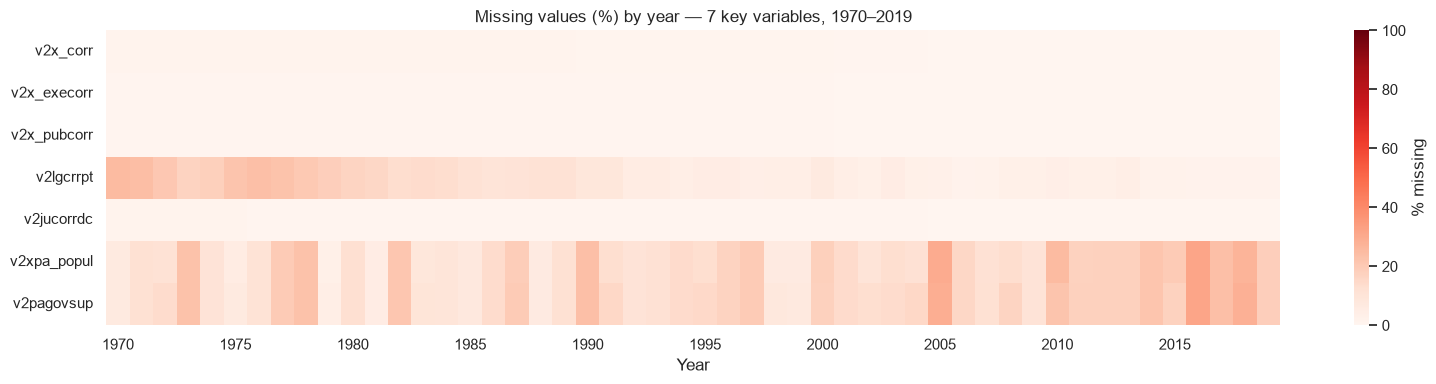

In [6]:
heatmap_data = missing_wide.select(KEY_VARIABLES).to_numpy().T  # shape (7, n_years)
years = missing_wide["year"].to_list()

fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(
    heatmap_data,
    cmap="Reds",
    vmin=0,
    vmax=100,
    yticklabels=KEY_VARIABLES,
    xticklabels=[y if y % 5 == 0 else "" for y in years],
    cbar_kws={"label": "% missing"},
    ax=ax,
)
ax.set_title("Missing values (%) by year — 7 key variables, 1970–2019")
ax.set_xlabel("Year")
plt.xticks(rotation=0)
fig.tight_layout()
plt.show()

The V-Party rows (`v2xpa_popul`, `v2pagovsup`) show much higher and spikier missingness
than the V-Dem corruption rows, because V-Party is sparse outside election years — this
is the same pattern as the line chart above, expressed as missingness rather than country
counts. `v2lgcrrpt` is structurally higher than the other corruption variables because it
is set to missing for countries without a legislature.

### 1c. Summary table (report-ready)

In [7]:
var_counts = pl.read_database(
    f"""
    SELECT 'v2x_corr' AS variable, 'vdem_country_year' AS source_table,
           COUNT(*) AS n_total, COUNT(v2x_corr) AS n_non_null
    FROM raw.vdem_country_year WHERE year BETWEEN {ANALYSIS_START_YEAR} AND {ANALYSIS_END_YEAR}
    UNION ALL
    SELECT 'v2x_execorr', 'vdem_country_year', COUNT(*), COUNT(v2x_execorr)
    FROM raw.vdem_country_year WHERE year BETWEEN {ANALYSIS_START_YEAR} AND {ANALYSIS_END_YEAR}
    UNION ALL
    SELECT 'v2x_pubcorr', 'vdem_country_year', COUNT(*), COUNT(v2x_pubcorr)
    FROM raw.vdem_country_year WHERE year BETWEEN {ANALYSIS_START_YEAR} AND {ANALYSIS_END_YEAR}
    UNION ALL
    SELECT 'v2lgcrrpt', 'vdem_country_year', COUNT(*), COUNT(v2lgcrrpt)
    FROM raw.vdem_country_year WHERE year BETWEEN {ANALYSIS_START_YEAR} AND {ANALYSIS_END_YEAR}
    UNION ALL
    SELECT 'v2jucorrdc', 'vdem_country_year', COUNT(*), COUNT(v2jucorrdc)
    FROM raw.vdem_country_year WHERE year BETWEEN {ANALYSIS_START_YEAR} AND {ANALYSIS_END_YEAR}
    UNION ALL
    SELECT 'v2xpa_popul', 'vparty_country_party_date', COUNT(*), COUNT(v2xpa_popul)
    FROM raw.vparty_country_party_date WHERE year BETWEEN {ANALYSIS_START_YEAR} AND {ANALYSIS_END_YEAR}
    UNION ALL
    SELECT 'v2pagovsup', 'vparty_country_party_date', COUNT(*), COUNT(v2pagovsup)
    FROM raw.vparty_country_party_date WHERE year BETWEEN {ANALYSIS_START_YEAR} AND {ANALYSIS_END_YEAR}
    """,
    con,
)

# Static metadata, documented in notes_for_report.md — "Variables of Interest".
metadata = pl.DataFrame({
    "variable": KEY_VARIABLES,
    "description": [
        "Composite political corruption index",
        "Executive corruption index",
        "Public sector corruption index",
        "Legislative corruption (missing if no legislature)",
        "Judicial corruption decisions",
        "Populism index (party-level)",
        "Party government status (0=senior governing partner)",
    ],
    "coding_direction": [
        "0=clean, 1=corrupt",
        "0=clean, 1=corrupt",
        "0=clean, 1=corrupt",
        "0=corrupt, 4=clean",
        "0=corrupt, 4=clean",
        "0=not populist, 1=populist",
        "categorical (0-4)",
    ],
})

summary_table = (
    metadata
    .join(var_counts, on="variable", how="left")
    .with_columns((100 * pl.col("n_non_null") / pl.col("n_total")).round(1).alias("pct_non_null"))
    .select([
        "variable", "source_table", "description", "coding_direction",
        "n_total", "n_non_null", "pct_non_null",
    ])
)
summary_table

variable,source_table,description,coding_direction,n_total,n_non_null,pct_non_null
str,str,str,str,i64,i64,f64
"""v2x_corr""","""vdem_country_year""","""Composite political corruption…","""0=clean, 1=corrupt""",8454,8388,99.2
"""v2x_execorr""","""vdem_country_year""","""Executive corruption index""","""0=clean, 1=corrupt""",8454,8423,99.6
"""v2x_pubcorr""","""vdem_country_year""","""Public sector corruption index""","""0=clean, 1=corrupt""",8454,8423,99.6
"""v2lgcrrpt""","""vdem_country_year""","""Legislative corruption (missin…","""0=corrupt, 4=clean""",8454,7707,91.2
"""v2jucorrdc""","""vdem_country_year""","""Judicial corruption decisions""","""0=corrupt, 4=clean""",8454,8413,99.5
"""v2xpa_popul""","""vparty_country_party_date""","""Populism index (party-level)""","""0=not populist, 1=populist""",7518,6307,83.9
"""v2pagovsup""","""vparty_country_party_date""","""Party government status (0=sen…","""categorical (0-4)""",7518,6280,83.5


## Section 2 — Distribution of the populism score (governing party)

### 2a. Histogram of `v2xpa_popul` for senior governing parties

Restricting to senior governing parties (`v2pagovsup == 0`) within 1970-2019 — the same population used for the primary populist-governance measure (see `notes_for_report.md`, Methodology Decisions). Mean, median, and 75th percentile are overlaid to inform an empirical threshold for "populist government".

In [8]:
gov_popul = pl.read_database(
    f"""
    SELECT v2xpa_popul
    FROM raw.vparty_country_party_date
    WHERE v2pagovsup = 0
      AND year BETWEEN {ANALYSIS_START_YEAR} AND {ANALYSIS_END_YEAR}
      AND v2xpa_popul IS NOT NULL
    """,
    con,
)

popul_values = gov_popul["v2xpa_popul"]
popul_mean = popul_values.mean()
popul_median = popul_values.median()
popul_p75 = popul_values.quantile(0.75)

popul_mean, popul_median, popul_p75

(0.3296781326781327, 0.274, 0.47)

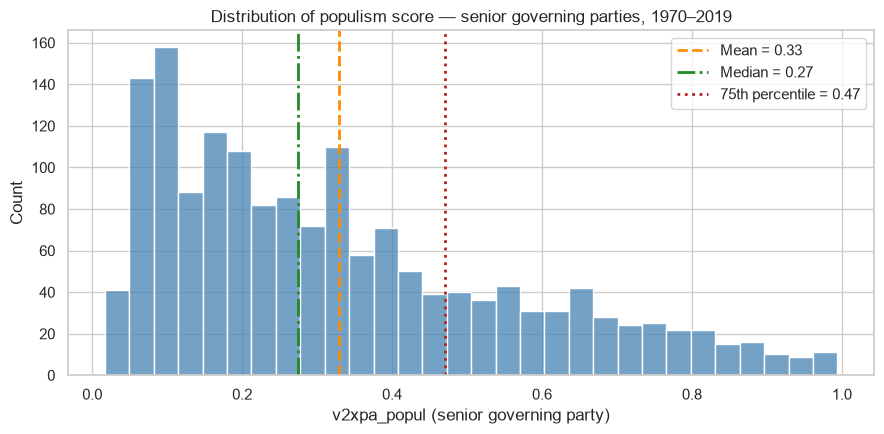

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(popul_values, bins=30, color="steelblue", ax=ax)

ax.axvline(popul_mean, color="darkorange", linestyle="--", linewidth=2,
           label=f"Mean = {popul_mean:.2f}")
ax.axvline(popul_median, color="forestgreen", linestyle="-.", linewidth=2,
           label=f"Median = {popul_median:.2f}")
ax.axvline(popul_p75, color="firebrick", linestyle=":", linewidth=2,
           label=f"75th percentile = {popul_p75:.2f}")

ax.set_xlabel("v2xpa_popul (senior governing party)")
ax.set_ylabel("Count")
ax.set_title("Distribution of populism score — senior governing parties, 1970–2019")
ax.legend()
fig.tight_layout()
plt.show()

### 2b. Evolution over time: global mean populism of governing parties

Annual mean of `v2xpa_popul` across all senior governing parties, with a 5-year rolling mean to smooth single-year noise (each year has only ~30-40 observations, see Section 1a).

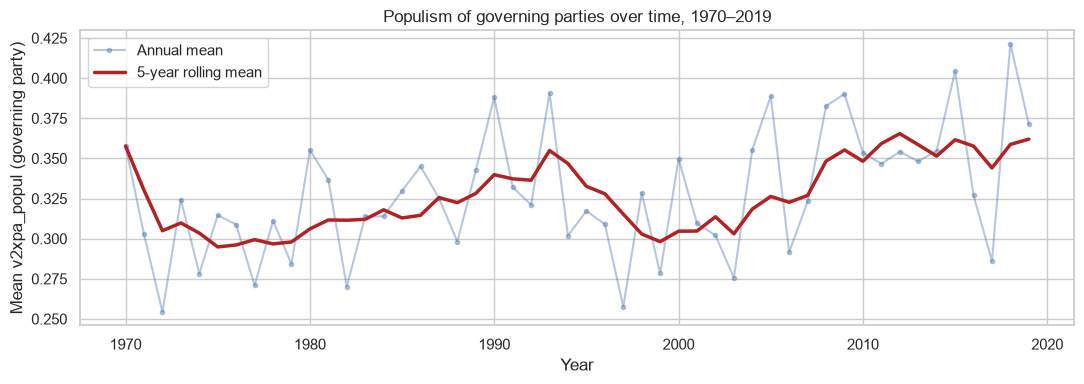

In [10]:
yearly_popul = pl.read_database(
    f"""
    SELECT year, AVG(v2xpa_popul) AS mean_popul
    FROM raw.vparty_country_party_date
    WHERE v2pagovsup = 0
      AND year BETWEEN {ANALYSIS_START_YEAR} AND {ANALYSIS_END_YEAR}
      AND v2xpa_popul IS NOT NULL
    GROUP BY year ORDER BY year
    """,
    con,
).with_columns(
    pl.col("mean_popul").rolling_mean(window_size=5, min_samples=1).alias("rolling_mean_5y")
)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(yearly_popul["year"], yearly_popul["mean_popul"],
        marker="o", markersize=3, alpha=0.4, label="Annual mean")
ax.plot(yearly_popul["year"], yearly_popul["rolling_mean_5y"],
        linewidth=2.5, color="firebrick", label="5-year rolling mean")
ax.set_xlabel("Year")
ax.set_ylabel("Mean v2xpa_popul (governing party)")
ax.set_title("Populism of governing parties over time, 1970–2019")
ax.legend()
fig.tight_layout()
plt.show()

### 2c. Top 20 most populist governing party-years (sanity check)

Checking that well-known populist governments surface near the top of the ranking — a basic validity check on `v2xpa_popul` before relying on it.

In [11]:
top20_popul = pl.read_database(
    f"""
    SELECT v2paenname AS party, country_name AS country, year, v2xpa_popul
    FROM raw.vparty_country_party_date
    WHERE v2pagovsup = 0
      AND year BETWEEN {ANALYSIS_START_YEAR} AND {ANALYSIS_END_YEAR}
      AND v2xpa_popul IS NOT NULL
    ORDER BY v2xpa_popul DESC
    LIMIT 20
    """,
    con,
)
top20_popul

party,country,year,v2xpa_popul
str,str,i64,f64
"""Fifth Republic Movement""","""Venezuela""",1998,0.994
"""Fifth Republic Movement""","""Venezuela""",2000,0.994
"""Fifth Republic Movement""","""Venezuela""",2005,0.994
"""United Socialist Party of Vene…","""Venezuela""",2010,0.986
"""United Socialist Party of Vene…","""Venezuela""",2015,0.986
"""National Regeneration Movement""","""Mexico""",2018,0.98
"""PAIS Alliance""","""Ecuador""",2007,0.977
"""Law and Justice""","""Poland""",2015,0.974
"""PAIS Alliance""","""Ecuador""",2009,0.968


### 2d. Regional comparison

Governing-party populism joined to V-Dem's `e_regiongeo` (19-category UN geoscheme) on `(country_id, year)`, grouped to its full label set.

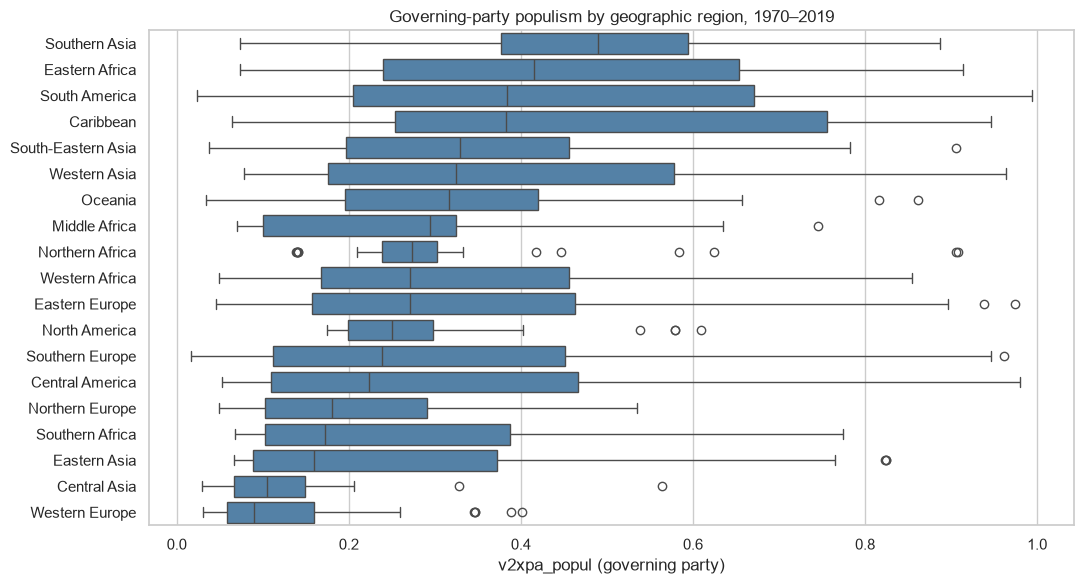

In [12]:
REGIONGEO_LABELS = {
    1: "Western Europe", 2: "Northern Europe", 3: "Southern Europe",
    4: "Eastern Europe", 5: "Northern Africa", 6: "Western Africa",
    7: "Middle Africa", 8: "Eastern Africa", 9: "Southern Africa",
    10: "Western Asia", 11: "Central Asia", 12: "Eastern Asia",
    13: "South-Eastern Asia", 14: "Southern Asia", 15: "Oceania",
    16: "North America", 17: "Central America", 18: "South America",
    19: "Caribbean",
}

regional_popul = pl.read_database(
    f"""
    SELECT vp.v2xpa_popul, vd.e_regiongeo
    FROM raw.vparty_country_party_date vp
    JOIN raw.vdem_country_year vd
      ON vp.country_id = vd.country_id AND vp.year = vd.year
    WHERE vp.v2pagovsup = 0
      AND vp.year BETWEEN {ANALYSIS_START_YEAR} AND {ANALYSIS_END_YEAR}
      AND vp.v2xpa_popul IS NOT NULL
    """,
    con,
).with_columns(
    pl.col("e_regiongeo").replace_strict(REGIONGEO_LABELS, return_dtype=pl.Utf8).alias("region")
)

region_order = (
    regional_popul.group_by("region").agg(pl.col("v2xpa_popul").median())
    .sort("v2xpa_popul", descending=True)["region"].to_list()
)

fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(
    x=regional_popul["v2xpa_popul"].to_numpy(),
    y=regional_popul["region"].to_numpy(),
    order=region_order, color="steelblue", ax=ax,
)
ax.set_xlabel("v2xpa_popul (governing party)")
ax.set_ylabel("")
ax.set_title("Governing-party populism by geographic region, 1970–2019")
fig.tight_layout()
plt.show()

## Section 2 — Findings & report notes

- Threshold for 'populist government' to be decided empirically based on distribution — see section 2a.
- The annual mean drifts upward over the window (~0.30 in the 1970s vs. ~0.36 in the 2010s); the 5-year rolling mean shows the increase is gradual and noisy year-to-year, not a sharp post-2010 break in this aggregate series.
- The top-20 ranking is dominated by widely-recognized populist governments (Chávez/Venezuela, Correa/Ecuador, Morales/Bolivia, Kaczyński's PiS/Poland, Erdoğan's AKP/Turkey) — a useful validity check on `v2xpa_popul`. Some frequently-cited cases score only moderately (Bolsonaro's PSL ≈0.35, Orbán's Fidesz ≈0.80-0.83, Trump's GOP ≈0.40-0.54), so the index should be read as anti-elite/people-centric *rhetoric*, not a general populism brand.
- Western and Northern Europe have the lowest median governing-party populism; South America and the Caribbean have the highest — regional fixed effects or clustering will matter in the regression stage.

## Section 3 — Distribution of the corruption index (country-year)

Mirrors Section 2's structure, applied to the outcome variable `v2x_corr` (composite political corruption index, country-year grain, all V-Dem countries — not restricted to governing parties). Remember: `v2x_corr` runs **0 = clean, 1 = most corrupt** (reverse-coded, see Section 1's variable table).

### 3a. Histogram of `v2x_corr`, 1970–2019

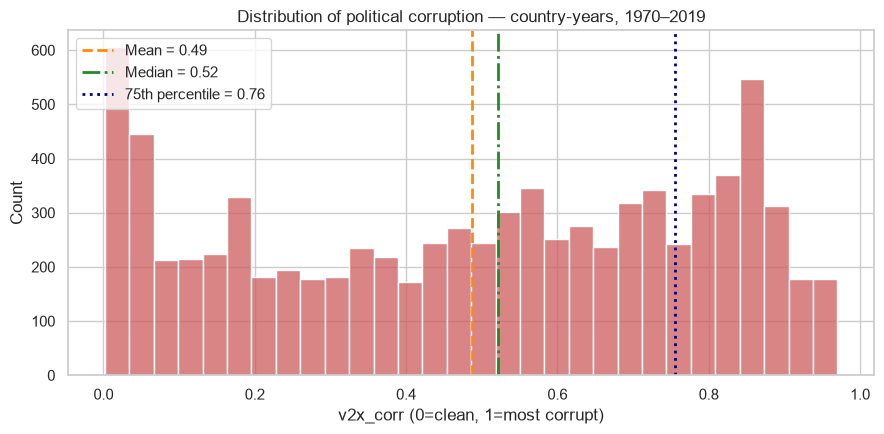

(8388, 0.48734775870290886, 0.521, 0.756)

In [13]:
corr_values = pl.read_database(
    f"""
    SELECT v2x_corr
    FROM raw.vdem_country_year
    WHERE year BETWEEN {ANALYSIS_START_YEAR} AND {ANALYSIS_END_YEAR}
      AND v2x_corr IS NOT NULL
    """,
    con,
)["v2x_corr"]

corr_mean = corr_values.mean()
corr_median = corr_values.median()
corr_p75 = corr_values.quantile(0.75)

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(corr_values, bins=30, color="indianred", ax=ax)
ax.axvline(corr_mean, color="darkorange", linestyle="--", linewidth=2,
           label=f"Mean = {corr_mean:.2f}")
ax.axvline(corr_median, color="forestgreen", linestyle="-.", linewidth=2,
           label=f"Median = {corr_median:.2f}")
ax.axvline(corr_p75, color="navy", linestyle=":", linewidth=2,
           label=f"75th percentile = {corr_p75:.2f}")
ax.set_xlabel("v2x_corr (0=clean, 1=most corrupt)")
ax.set_ylabel("Count")
ax.set_title("Distribution of political corruption — country-years, 1970–2019")
ax.legend()
fig.tight_layout()
plt.show()

corr_values.len(), corr_mean, corr_median, corr_p75

### 3b. Evolution over time: global mean corruption

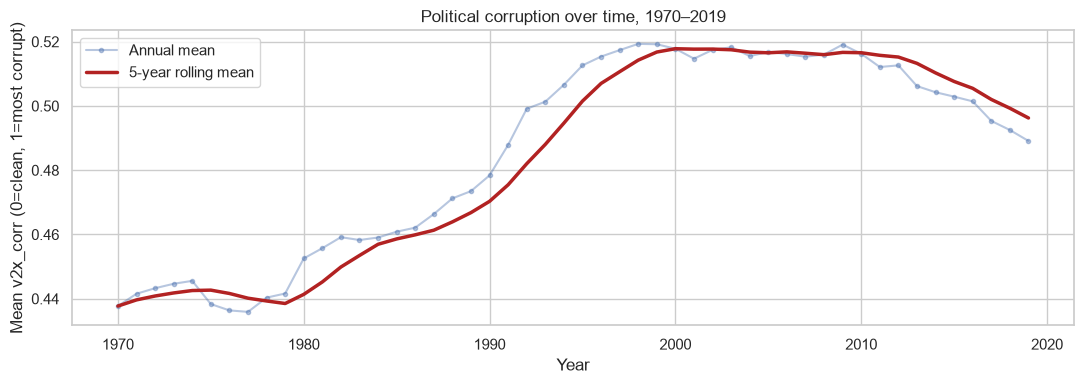

In [14]:
yearly_corr = pl.read_database(
    f"""
    SELECT year, AVG(v2x_corr) AS mean_corr
    FROM raw.vdem_country_year
    WHERE year BETWEEN {ANALYSIS_START_YEAR} AND {ANALYSIS_END_YEAR}
      AND v2x_corr IS NOT NULL
    GROUP BY year ORDER BY year
    """,
    con,
).with_columns(
    pl.col("mean_corr").rolling_mean(window_size=5, min_samples=1).alias("rolling_mean_5y")
)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(yearly_corr["year"], yearly_corr["mean_corr"],
        marker="o", markersize=3, alpha=0.4, label="Annual mean")
ax.plot(yearly_corr["year"], yearly_corr["rolling_mean_5y"],
        linewidth=2.5, color="firebrick", label="5-year rolling mean")
ax.set_xlabel("Year")
ax.set_ylabel("Mean v2x_corr (0=clean, 1=most corrupt)")
ax.set_title("Political corruption over time, 1970–2019")
ax.legend()
fig.tight_layout()
plt.show()

### 3c. Cleanest and most corrupt country-years (sanity check)

Checking that `v2x_corr`'s orientation and scale behave as documented: consolidated Nordic democracies should anchor the clean end, fragile/conflict states the corrupt end.

In [15]:
cleanest = pl.read_database(
    f"""
    SELECT country_name AS country, year, v2x_corr
    FROM raw.vdem_country_year
    WHERE year BETWEEN {ANALYSIS_START_YEAR} AND {ANALYSIS_END_YEAR}
      AND v2x_corr IS NOT NULL
    ORDER BY v2x_corr ASC
    LIMIT 10
    """,
    con,
)
cleanest

country,year,v2x_corr
str,i64,f64
"""Denmark""",1970,0.002
"""Denmark""",1971,0.002
"""Denmark""",1972,0.002
"""Denmark""",1973,0.002
"""Denmark""",1974,0.002
"""Denmark""",1975,0.002
"""Denmark""",1976,0.002
"""Denmark""",1977,0.002
"""Denmark""",1978,0.002


In [16]:
most_corrupt = pl.read_database(
    f"""
    SELECT country_name AS country, year, v2x_corr
    FROM raw.vdem_country_year
    WHERE year BETWEEN {ANALYSIS_START_YEAR} AND {ANALYSIS_END_YEAR}
      AND v2x_corr IS NOT NULL
    ORDER BY v2x_corr DESC
    LIMIT 10
    """,
    con,
)
most_corrupt

country,year,v2x_corr
str,i64,f64
"""Equatorial Guinea""",1979,0.97
"""Venezuela""",2013,0.968
"""Venezuela""",2014,0.966
"""Democratic Republic of the Con…",2018,0.966
"""Madagascar""",2011,0.966
"""Madagascar""",2012,0.966
"""Chad""",2013,0.965
"""Chad""",2015,0.965
"""Chad""",2016,0.965


### 3d. Regional comparison

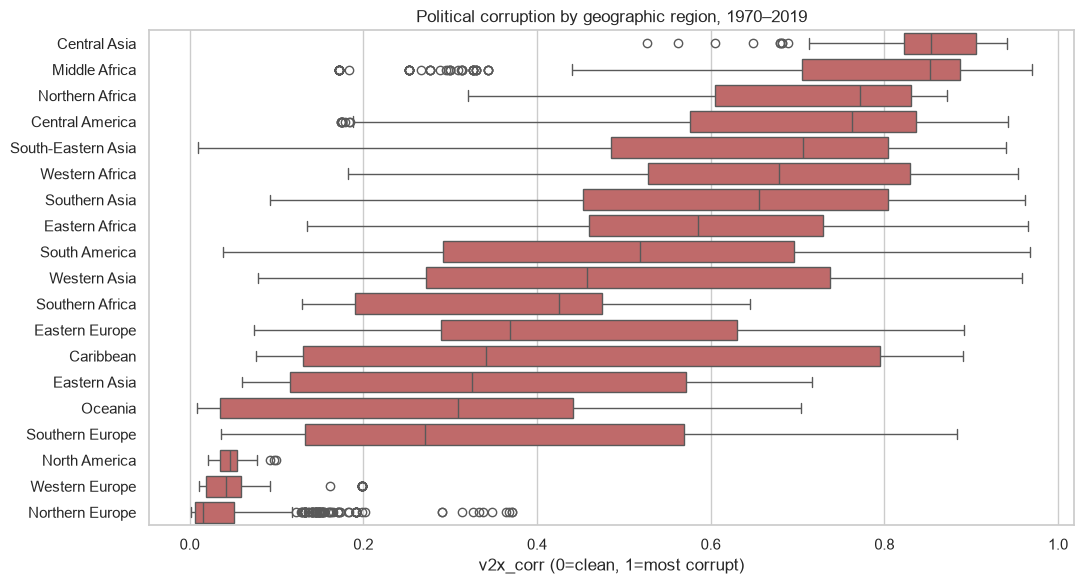

In [17]:
regional_corr = pl.read_database(
    f"""
    SELECT v2x_corr, e_regiongeo
    FROM raw.vdem_country_year
    WHERE year BETWEEN {ANALYSIS_START_YEAR} AND {ANALYSIS_END_YEAR}
      AND v2x_corr IS NOT NULL
    """,
    con,
).with_columns(
    pl.col("e_regiongeo").replace_strict(REGIONGEO_LABELS, return_dtype=pl.Utf8).alias("region")
)

corr_region_order = (
    regional_corr.group_by("region").agg(pl.col("v2x_corr").median())
    .sort("v2x_corr", descending=True)["region"].to_list()
)

fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(
    x=regional_corr["v2x_corr"].to_numpy(),
    y=regional_corr["region"].to_numpy(),
    order=corr_region_order, color="indianred", ax=ax,
)
ax.set_xlabel("v2x_corr (0=clean, 1=most corrupt)")
ax.set_ylabel("")
ax.set_title("Political corruption by geographic region, 1970–2019")
fig.tight_layout()
plt.show()

## Section 3 — Findings & report notes

- Unlike populism's unimodal shape (Section 2a), `v2x_corr` is **bimodal**: a cluster of clean democracies near 0 and a second cluster of highly corrupt states near 0.85, with relatively few country-years in between — corruption looks more like a regime-type split than a smooth continuum.
- Sanity check passes: Denmark anchors the clean end (v2x_corr=0.002) across the 1970s; Equatorial Guinea, Venezuela, DR Congo, Madagascar, and Chad anchor the corrupt end (≈0.96-0.97) — confirms the reverse-coding direction is correct.
- Regional pattern mirrors the populism regional pattern loosely but is more extreme: Western Europe and North America are far cleaner (mean ≈0.05) than Central Asia (mean ≈0.85); this regional clustering will need to be addressed (fixed effects / clustered SEs) so it isn't mistaken for a populism effect.
- Global mean corruption drifts up only mildly over 1970-2019 (≈0.44 in the 1970s vs. ≈0.50 in the 2010s) — a much smaller move than the regional gaps in the boxplot, suggesting cross-sectional (between-country) variation dominates over time variation, which is exactly what the within-country fixed-effects design in Section 9 is meant to isolate.

## Section 4 — Cross-sectional comparison: populist vs. non-populist governments

⚠️ **The 0.47 threshold (75th percentile of `v2xpa_popul`, from Section 2a) is used here ONLY as a visual/descriptive label for "high-populism governments" (top quartile). It is not a model specification** — the primary analysis (Section 9) treats populism as continuous (see `notes_for_report.md`, Methodology Decisions). Everything in this section is a group comparison, not a regression.

### 4a. Country-year panel: governing-party populism × corruption (1970–2019)

Build the panel used for the rest of Section 4: senior governing party (`v2pagovsup == 0`) populism, forward-filled within country from each election to the next (per `notes_for_report.md`, Methodology Decisions), inner-joined to V-Dem's corruption variables.

Direction note: `v2lgcrrpt`/`v2jucorrdc`'s plain values are latent z-scale estimates (~−3…+4, *higher = cleaner*) — the opposite convention from the 0–1 `v2x_*` D-indices (*higher = more corrupt*). To compare all five dimensions on one consistent scale, the `_ord` (0–4) versions are rescaled to `(4 - ord) / 4`, giving 0–1 variables where higher always means more corrupt, matching `v2x_corr`.

In [18]:
gov_popul_raw = pl.read_database(
    f"""
    SELECT country_id, year, AVG(v2xpa_popul) AS v2xpa_popul
    FROM raw.vparty_country_party_date
    WHERE v2pagovsup = 0
      AND year BETWEEN {ANALYSIS_START_YEAR} AND {ANALYSIS_END_YEAR}
      AND v2xpa_popul IS NOT NULL
    GROUP BY country_id, year
    """,
    con,
)  # AVG collapses the ~20 country-years with duplicate senior-governing-party rows

year_grid = pl.DataFrame({"year": list(range(ANALYSIS_START_YEAR, ANALYSIS_END_YEAR + 1))})
country_grid = gov_popul_raw.select("country_id").unique()
full_grid = country_grid.join(year_grid, how="cross")

panel_popul = (
    full_grid
    .join(gov_popul_raw, on=["country_id", "year"], how="left")
    .sort(["country_id", "year"])
    .with_columns(pl.col("v2xpa_popul").forward_fill().over("country_id"))
    .filter(pl.col("v2xpa_popul").is_not_null())  # drop years before a country's first coded election
)

corruption_vars = pl.read_database(
    f"""
    SELECT country_id, year, country_name,
           v2x_corr, v2x_execorr, v2x_pubcorr, v2lgcrrpt_ord, v2jucorrdc_ord
    FROM raw.vdem_country_year
    WHERE year BETWEEN {ANALYSIS_START_YEAR} AND {ANALYSIS_END_YEAR}
    """,
    con,
).with_columns([
    ((4 - pl.col("v2lgcrrpt_ord")) / 4).alias("v2lgcrrpt_01"),
    ((4 - pl.col("v2jucorrdc_ord")) / 4).alias("v2jucorrdc_01"),
])

panel = panel_popul.join(corruption_vars, on=["country_id", "year"], how="inner")

CORRUPTION_VARS = ["v2x_corr", "v2x_execorr", "v2x_pubcorr", "v2lgcrrpt_01", "v2jucorrdc_01"]
POPUL_THRESHOLD = 0.47  # 75th percentile — visual label ONLY, see note above
panel = panel.with_columns(
    pl.when(pl.col("v2xpa_popul") > POPUL_THRESHOLD)
    .then(pl.lit("high-populism (>0.47)"))
    .otherwise(pl.lit("lower-populism (<=0.47)"))
    .alias("populism_group")
)

print(panel.shape, "| countries:", panel["country_id"].n_unique())
panel.head()

(6909, 12) | countries: 163


country_id,year,v2xpa_popul,country_name,v2x_corr,v2x_execorr,v2x_pubcorr,v2lgcrrpt_ord,v2jucorrdc_ord,v2lgcrrpt_01,v2jucorrdc_01,populism_group
i64,i64,f64,str,f64,f64,f64,i64,i64,f64,f64,str
3,1970,0.199,"""Mexico""",0.82,0.836,0.764,0,2,1.0,0.5,"""lower-populism (<=0.47)"""
3,1971,0.199,"""Mexico""",0.82,0.836,0.764,0,2,1.0,0.5,"""lower-populism (<=0.47)"""
3,1972,0.199,"""Mexico""",0.82,0.836,0.764,0,2,1.0,0.5,"""lower-populism (<=0.47)"""
3,1973,0.196,"""Mexico""",0.82,0.836,0.764,0,2,1.0,0.5,"""lower-populism (<=0.47)"""
3,1974,0.196,"""Mexico""",0.82,0.836,0.764,0,2,1.0,0.5,"""lower-populism (<=0.47)"""


### 4b. Boxplots: corruption dimensions by populism group

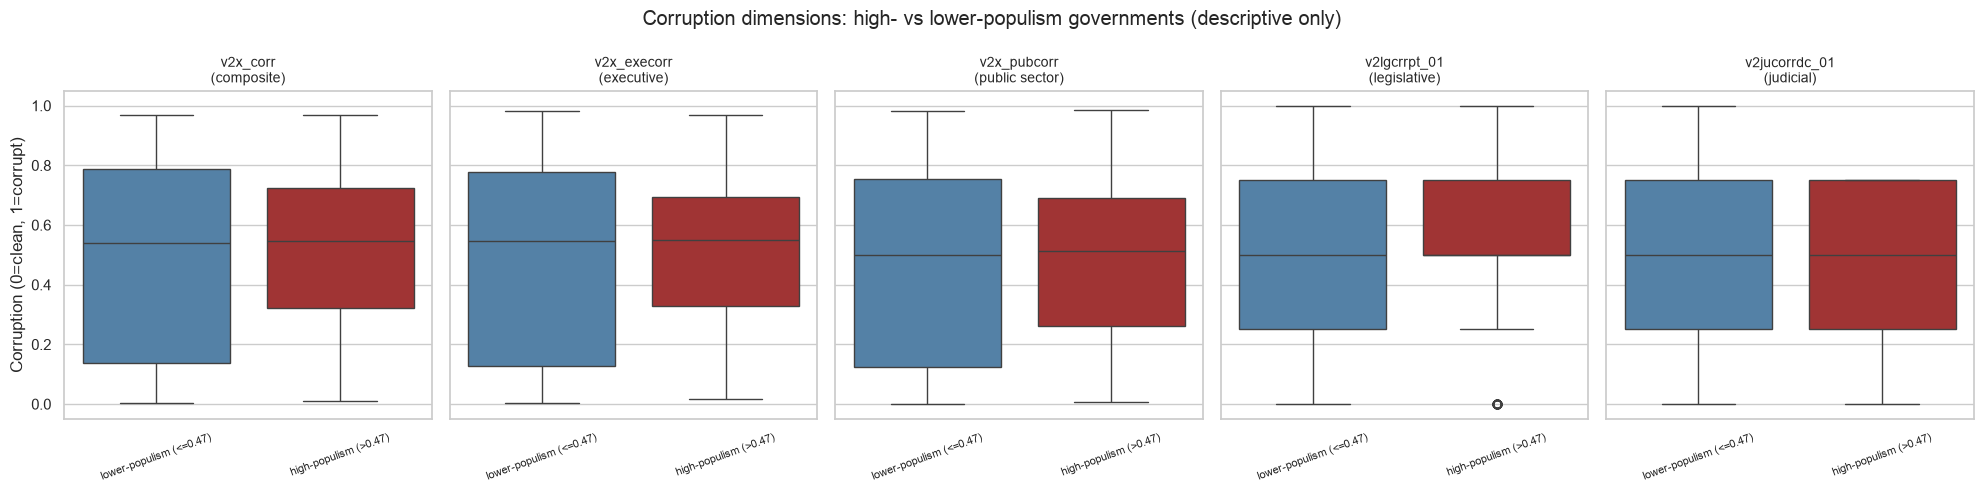

In [19]:
GROUP_ORDER = ["lower-populism (<=0.47)", "high-populism (>0.47)"]
VAR_LABELS = {
    "v2x_corr": "v2x_corr\n(composite)",
    "v2x_execorr": "v2x_execorr\n(executive)",
    "v2x_pubcorr": "v2x_pubcorr\n(public sector)",
    "v2lgcrrpt_01": "v2lgcrrpt_01\n(legislative)",
    "v2jucorrdc_01": "v2jucorrdc_01\n(judicial)",
}

fig, axes = plt.subplots(1, 5, figsize=(20, 5), sharey=True)
for ax, var in zip(axes, CORRUPTION_VARS):
    data = panel.filter(pl.col(var).is_not_null())
    sns.boxplot(
        x=data["populism_group"].to_numpy(),
        y=data[var].to_numpy(),
        order=GROUP_ORDER,
        hue=data["populism_group"].to_numpy(),
        palette={"lower-populism (<=0.47)": "steelblue", "high-populism (>0.47)": "firebrick"},
        legend=False,
        ax=ax,
    )
    ax.set_title(VAR_LABELS[var], fontsize=10)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20, labelsize=8)
axes[0].set_ylabel("Corruption (0=clean, 1=corrupt)")
fig.suptitle("Corruption dimensions: high- vs lower-populism governments (descriptive only)")
fig.tight_layout()
plt.show()

### 4c. Mann-Whitney U test + effect size (Cliff's delta / rank-biserial correlation)

In [20]:
from scipy.stats import mannwhitneyu

mwu_results = []
for var in CORRUPTION_VARS:
    data = panel.filter(pl.col(var).is_not_null())
    high = data.filter(pl.col("populism_group") == "high-populism (>0.47)")[var]
    low = data.filter(pl.col("populism_group") == "lower-populism (<=0.47)")[var]
    u_stat, p_value = mannwhitneyu(high.to_numpy(), low.to_numpy(), alternative="two-sided")
    n1, n2 = high.len(), low.len()
    # Cliff's delta == rank-biserial correlation for two independent samples
    cliffs_delta = 2 * u_stat / (n1 * n2) - 1
    mwu_results.append({
        "variable": var,
        "n_high": n1, "n_low": n2,
        "median_high": round(high.median(), 3), "median_low": round(low.median(), 3),
        "U": round(u_stat, 0), "p_value": p_value,
        "cliffs_delta": round(cliffs_delta, 3),
    })

mwu_results_df = pl.DataFrame(mwu_results).sort("cliffs_delta", descending=True)
mwu_results_df

variable,n_high,n_low,median_high,median_low,U,p_value,cliffs_delta
str,i64,i64,f64,f64,f64,f64,f64
"""v2lgcrrpt_01""",1648,4848,0.5,0.5,4.425349e6,8.3901e-12,0.108
"""v2jucorrdc_01""",1831,5078,0.5,0.5,5.054964e6,6.9442e-9,0.087
"""v2x_corr""",1831,5078,0.547,0.539,4.943729e6,0.000056,0.063
"""v2x_pubcorr""",1831,5078,0.512,0.501,4.915228e6,0.000273,0.057
"""v2x_execorr""",1831,5078,0.55,0.546,4.900406e6,0.000588,0.054


### 4d. Findings

- All five corruption dimensions are **higher (more corrupt) in high-populism governments**, and every difference is statistically significant (p < 0.001) — but this is driven by a large N (1,831 vs. 5,078 country-years), not by large effects: every Cliff's delta is in the "small" range (< 0.15 by conventional thresholds).
- **Legislative corruption (`v2lgcrrpt_01`, δ≈0.11) and judicial corruption (`v2jucorrdc_01`, δ≈0.09) show the largest descriptive gaps**; executive (δ≈0.05) and public-sector (δ≈0.06) corruption show the smallest. The composite (δ≈0.06) sits in between, as expected from an average of the four spheres.
- ⚠️ **This is a cross-sectional mean/median comparison only.** It says nothing about causal direction or confounders — countries with high-populism governments may simply have been more corrupt (or more autocratic, or from a more corrupt region — see Section 3d) *before* the populist party ever took office. Section 5's case studies probe this directly; Section 9's regression and lead-lag design is what can actually speak to direction.

## Section 5 — Country case studies: governing transitions

Five countries with a clear pre-populist baseline followed by a well-documented populist governing era inside 1970–2019: Venezuela (Chávez, 1999+), Hungary (Orbán/Fidesz, 2010+), Turkey (AKP/Erdoğan, 2002+), Bolivia (Morales, 2006–2019), Ecuador (Correa, 2007–2017).

Each plot shows governing-party `v2xpa_popul` (top panel) against the composite corruption index and three sub-dimensions (bottom panel), with vertical lines at the entry/exit year(s). `v2lgcrrpt` is left out of this panel (kept in Section 4's five-way comparison) so all four lines share the same 0–1, higher-is-more-corrupt direction without rescaling (`v2jucorrdc_01` substitutes for raw `v2jucorrdc`, same fix as Section 4a).

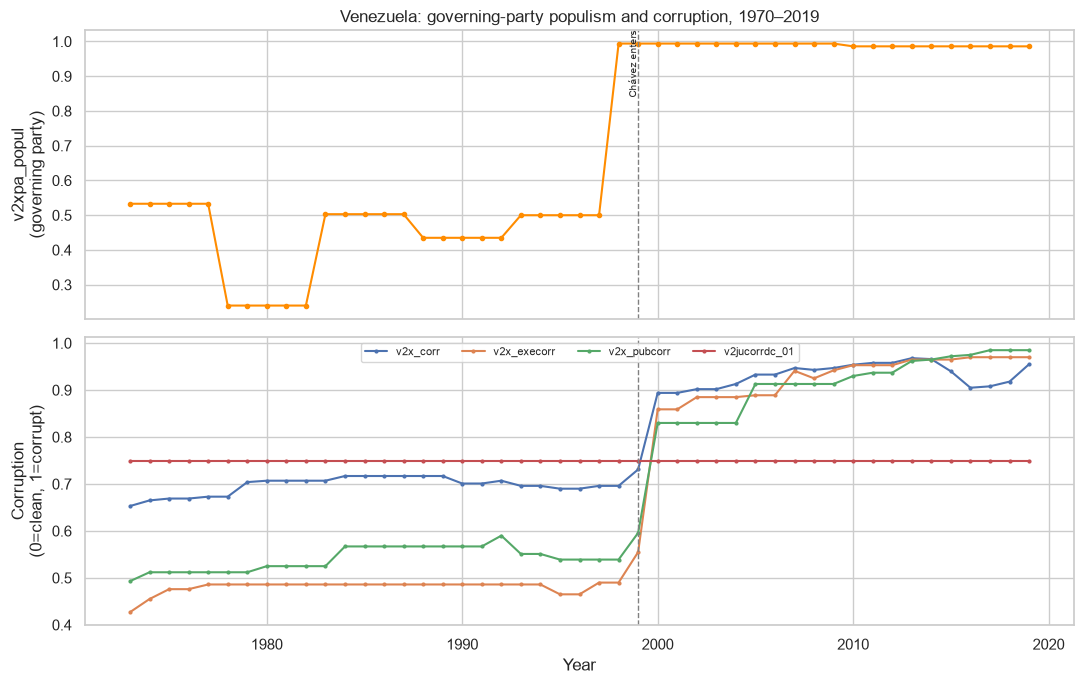

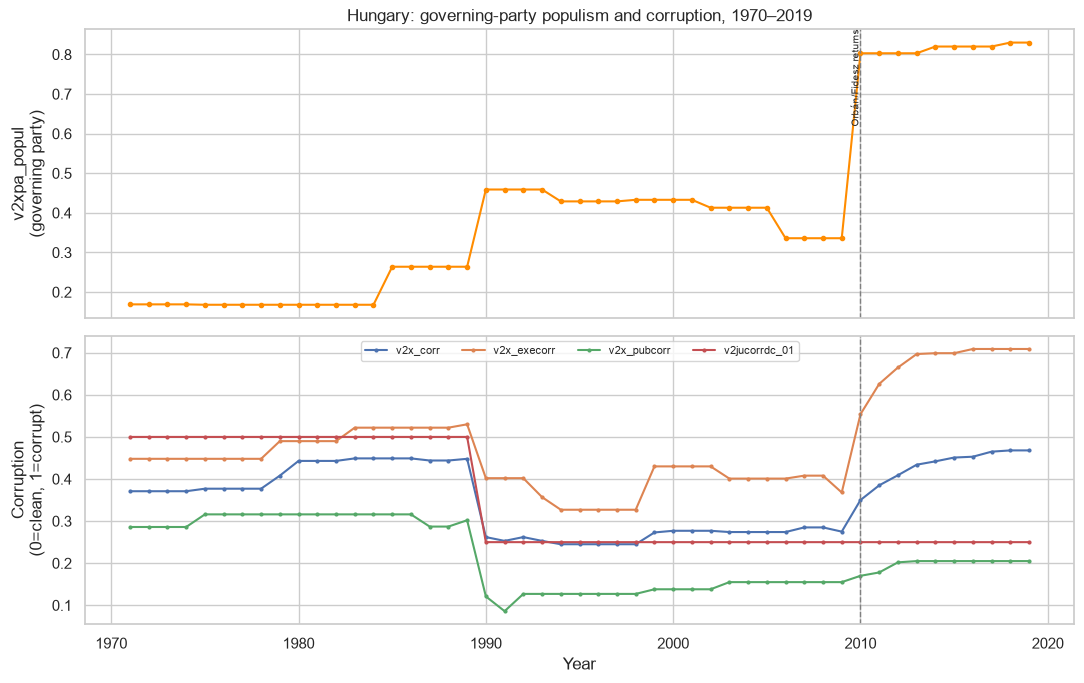

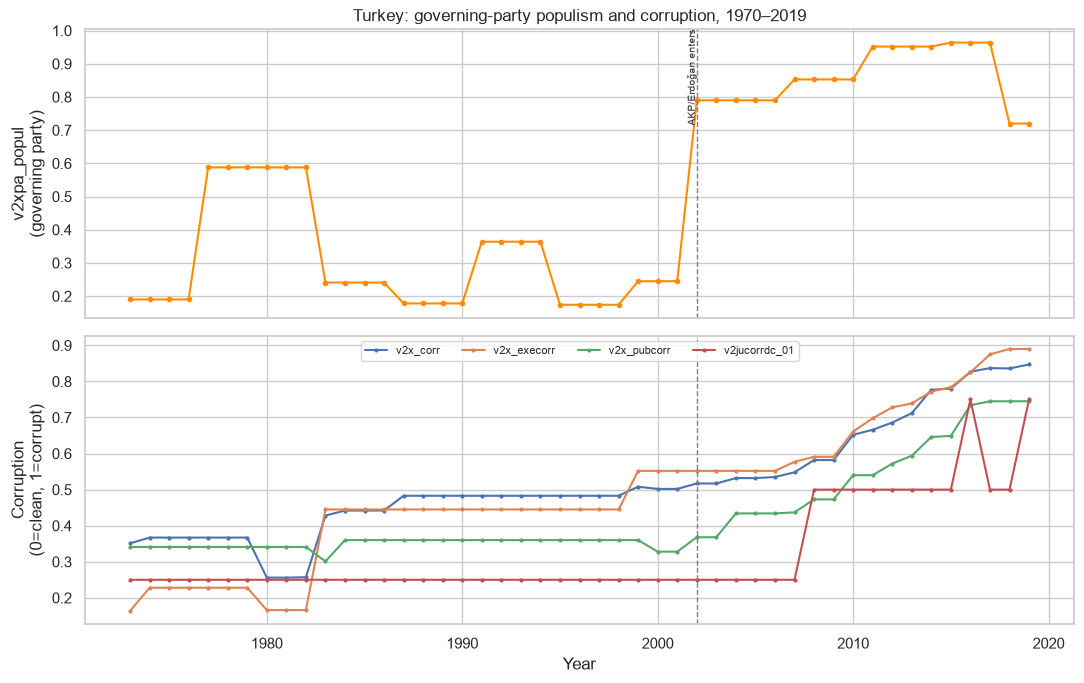

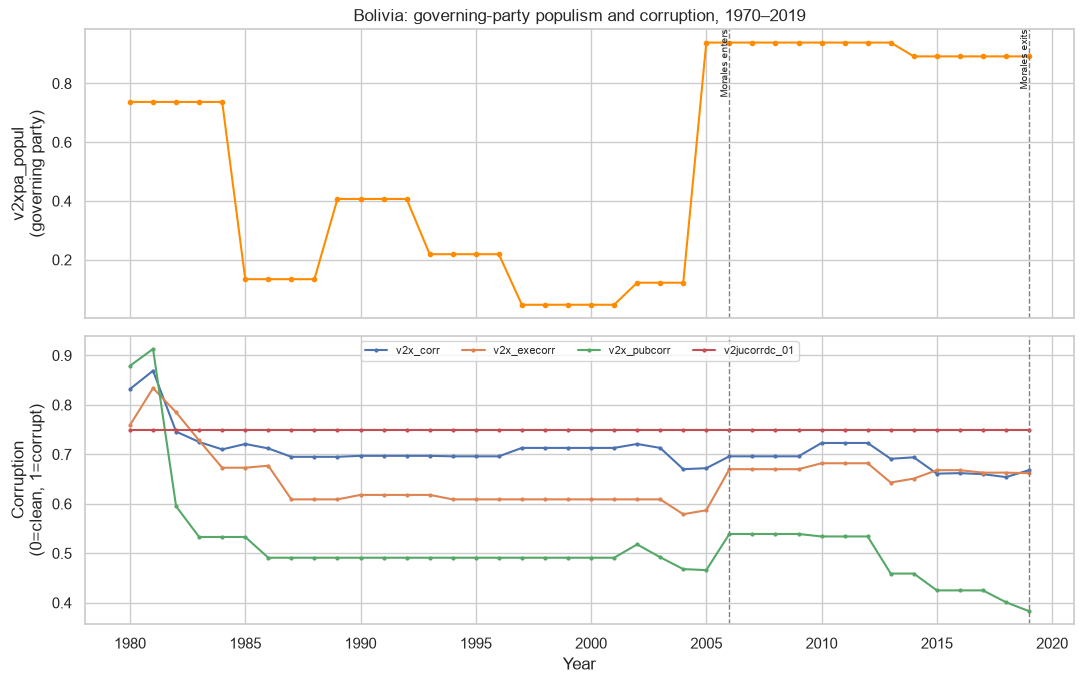

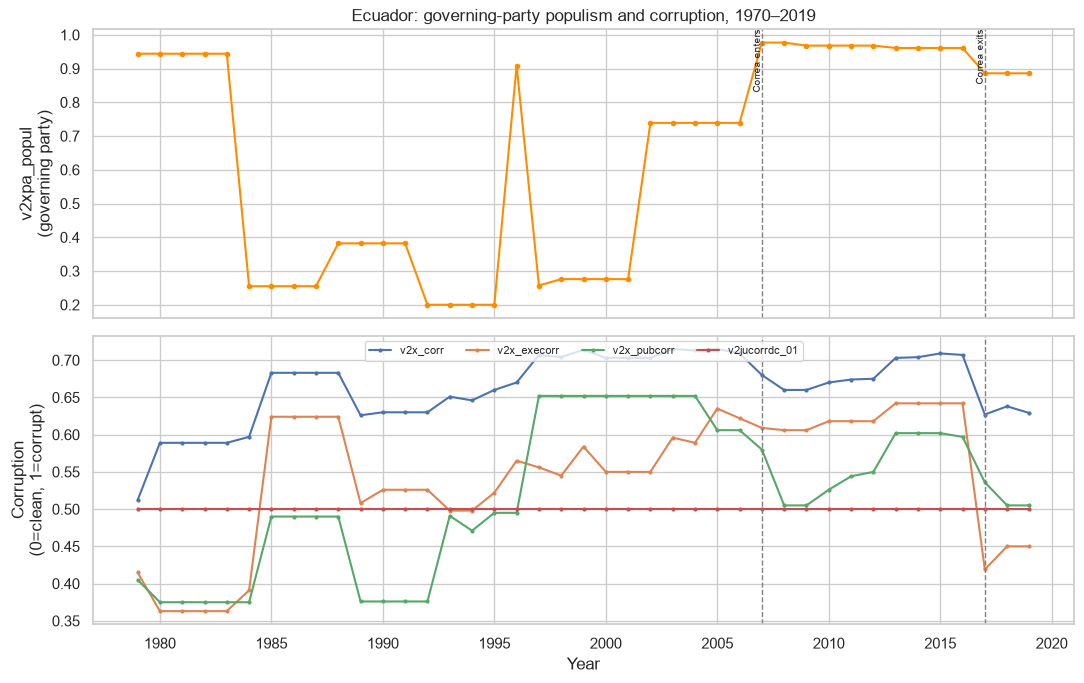

In [21]:
CASE_STUDY_CORRUPTION_VARS = ["v2x_corr", "v2x_execorr", "v2x_pubcorr", "v2jucorrdc_01"]

CASE_STUDY_COUNTRIES = [
    {"country_id": 51, "label": "Venezuela", "transitions": [(1999, "Chávez enters")]},
    {"country_id": 210, "label": "Hungary", "transitions": [(2010, "Orbán/Fidesz returns")]},
    {"country_id": 99, "label": "Turkey", "transitions": [(2002, "AKP/Erdoğan enters")]},
    {"country_id": 25, "label": "Bolivia", "transitions": [(2006, "Morales enters"), (2019, "Morales exits")]},
    {"country_id": 75, "label": "Ecuador", "transitions": [(2007, "Correa enters"), (2017, "Correa exits")]},
]


def plot_case_study(country_id, label, transitions):
    country_corr = pl.read_database(
        f"""
        SELECT country_id, year, v2x_corr, v2x_execorr, v2x_pubcorr, v2jucorrdc_ord
        FROM raw.vdem_country_year
        WHERE country_id = {country_id}
          AND year BETWEEN {ANALYSIS_START_YEAR} AND {ANALYSIS_END_YEAR}
        """,
        con,
    ).with_columns(((4 - pl.col("v2jucorrdc_ord")) / 4).alias("v2jucorrdc_01"))
    country_panel = (
        panel_popul.filter(pl.col("country_id") == country_id)
        .join(country_corr, on=["country_id", "year"], how="inner")
        .sort("year")
    )

    fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

    ax_top.plot(country_panel["year"], country_panel["v2xpa_popul"],
                color="darkorange", marker="o", markersize=3)
    ax_top.set_ylabel("v2xpa_popul\n(governing party)")
    ax_top.set_title(f"{label}: governing-party populism and corruption, 1970–2019")

    for var in CASE_STUDY_CORRUPTION_VARS:
        ax_bottom.plot(country_panel["year"], country_panel[var], marker="o", markersize=2, label=var)
    ax_bottom.set_ylabel("Corruption\n(0=clean, 1=corrupt)")
    ax_bottom.set_xlabel("Year")
    ax_bottom.legend(fontsize=8, ncol=4, loc="upper center")

    for ax in (ax_top, ax_bottom):
        for year, _ in transitions:
            ax.axvline(year, color="grey", linestyle="--", linewidth=1)
    for year, note in transitions:
        ax_top.annotate(note, xy=(year, 1.0), xycoords=("data", "axes fraction"),
                        rotation=90, fontsize=7, ha="right", va="top")

    fig.tight_layout()
    plt.show()


for case in CASE_STUDY_COUNTRIES:
    plot_case_study(**case)

### 5b. Findings

- **No single common pattern.** Comparing the 5-year mean of `v2x_corr` immediately before vs. after entry: Venezuela rises sharply (0.69 → 0.87, +0.17) and Hungary rises notably (0.28 → 0.40, +0.13); Turkey moves only slightly (0.50 → 0.53); Bolivia is essentially flat (0.70 → 0.70); Ecuador actually *declines* slightly (0.71 → 0.67).
- **Pre-existing corruption level matters more than the populist transition itself.** Venezuela, Bolivia, and Ecuador were already in the upper half of the corruption distribution *before* their populist leaders took office; only Hungary starts from a comparatively clean baseline and shows a clear post-entry rise — consistent with an "institutional capture" story specific to that case, not a general rule.
- **Sub-dimensions move together within a country** (the four lines in each bottom panel are highly correlated over time) — there is no case here where, say, executive corruption rises while judicial corruption falls. This is a single-country observation, not yet a property of the data established at panel scale (Section 4's group medians did differ by dimension).
- ⚠️ **The causal ambiguity is the point.** Whether populism is *driving* corruption (Hungary's pattern), arriving *into* an already-corrupt context (Bolivia/Ecuador's pattern), or genuinely unrelated to the corruption trend (Turkey/Ecuador's small or negative moves) cannot be settled by looking at five time series. This is exactly the motivation for Edoardo's lead-lag / causal-direction analysis in Section 9 — distinguishing "populism(t) → corruption(t+1)" from "corruption(t) → populism(t+1)" requires the full panel, not case-by-case inspection.

## EDA Conclusions (for Section 10 — Results)

1. **Populism and corruption have different distributional shapes.** Governing-party populism (`v2xpa_popul`) is unimodal and right-skewed with no natural break point (Section 2a) — this is why it is modeled as continuous rather than dichotomized. Corruption (`v2x_corr`) is bimodal — a clean-democracy cluster near 0 and a corrupt-state cluster near 0.85 (Section 3a) — closer to a regime-type split than a smooth continuum.
2. **All five corruption dimensions are descriptively higher in high-populism governments, but the effect sizes are small** (Cliff's delta 0.05-0.11 across 1,831 high-populism vs. 5,078 lower-populism country-years; Section 4c). Legislative and judicial corruption show the largest gaps; executive and public-sector the smallest — a candidate mechanism pattern, not yet a finding.
3. **Region is a far stronger discriminator of corruption than the populism split.** Mean `v2x_corr` ranges from ≈0.05 (Western Europe/North America) to ≈0.85 (Central Asia) across regions (Section 3d) — an order of magnitude larger than the high- vs. lower-populism gap. Any model that omits region or regime-type controls risks attributing a regional effect to populism.
4. **The five governing-transition case studies show no single pattern** (Section 5b): Venezuela and Hungary show a clear post-entry rise in corruption; Bolivia is flat; Ecuador slightly improves. Pre-existing corruption level before the populist party took office varies as much as the post-entry trajectory does.
5. **EDA alone cannot establish causal direction.** Cross-sectional comparisons (Section 4) and single-country time series (Section 5) are consistent with at least three stories — populism raises corruption, corruption breeds populism, or both are driven by a shared confounder (region, regime type, GDP) — and cannot distinguish between them. This is the explicit limitation the lead-lag design is meant to address.
6. **Data constraints bound what the full analysis can claim.** The panel is restricted to 1970-2019 (V-Party's expert-coding window; Section 1a/8a/8b), so it cannot speak to the most recent populist wave (Meloni, Trump's second term, etc.) and rests on ~1,628-6,909 country-years depending on the variable, with an unbalanced panel of 163-182 countries.
7. **Next steps for Vlad (regression) and Edoardo (causal direction):** (a) two-way fixed-effects panel regression of `v2x_corr` (and the four sub-dimensions) on continuous `v2xpa_popul`, with region/regime-type controls, to isolate within-country variation from the regional confounding found here; (b) lead-lag/Granger comparison of populism(t)→corruption(t+1,t+2) vs. corruption(t)→populism(t+1) to test the direction Section 5 could only speculate about; (c) formally re-test the legislative/judicial > executive/public-sector pattern from Section 4c as a decomposition, since it is currently only a descriptive, confound-laden signal.